## Project Framing 

### Problem Statement:
This project simulates an A/B test comparing the performance of two advertisement campaigns (Ad A and Ad B).  The goal is to determine whether one campaign leads to a higher user conversion rate and to provide a data-driven recommendation to stakeholders on which campaign to deploy.

### Objectives:
The analysis aims to:
* Evaluate the performance of two advertisement campaigns using conversion rate as the key metric.
* Determine whether any observed difference in conversion rate is statistically significant.
* Quantify the uncertainty around the estimated effect using confidence interval.
* Provide a recommendation to stakeholders on whether to adopt one campaign over the other or continue experimentation.
    
### Analytical Approach:
To address this problem, the following steps are conducted:
* Data cleaning and preprocessing
* Calculation of conversion rate for each group
* Hypothesis testing using a two-proportion z-test
* Estimation of confidence intervals for the difference in conversion rates
* Interpretation of results in a business context.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.analysis import two_proportion_test, confidence_interval_two_proportions


In [3]:
x_a, n_a = 24, 238
x_b, n_b = 33, 285

results = two_proportion_test(x_a, x_b, n_a, n_b)
print(results)

{'p_a': 0.10084033613445378, 'p_b': 0.11578947368421053, 'difference': 0.014949137549756741, 'z_score': 0.5463205094779096, 'p_value': 0.29242282028679045}


### Step 1 - Data Engineering

In [4]:
# import libraries
import pandas as pd
import numpy as np

# Create the number of participants in each ad_campaign
np.random.seed(24)
n_a = 250 
n_b = 300

# Attribute user_id to participants in each ad_campaign
user_adA = np.arange(1, n_a + 1)
user_adB = np.arange(n_a +1, n_a + n_b + 1)

# Products carried by the company
devices = ['Mobile','Desktop', 'Tablet']

device_a = np.random.choice(devices, size = n_a, p=[0.5,0.3,0.2])
device_b = np.random.choice(devices, size = n_b, p=[0.5,0.3,0.2])

# Period covered by the ad_campaign
dates = pd.date_range(start = '2025-03-01', end= '2025-06-01', freq= 'D')

date_a = np.random.choice(dates, size = n_a)
date_b = np.random.choice(dates, size = n_b)

# Conversion 
converted_a = np.random.binomial(1,0.09,n_a)
converted_b = np.random.binomial(1,0.11,n_b)

# Create each campaign DataFrame

df_a = pd.DataFrame({
    'user_id':user_adA,
    'device': device_a,
    'date': date_a,
    'converted': converted_a
})

df_b = pd.DataFrame({
    'user_id':user_adB,
    'device': device_b,
    'date': date_b,
    'converted': converted_b
})

print()
print()

#1. Add Missing Values

# select 5% of the observations
nan_rows = df_a.sample(frac = 0.05, random_state = 24).index
# Assign NaN to column  and date
cols = ['device','date']
df_a.loc[nan_rows, cols]= np.nan


#2. Add Duplicates Users

# Pick a 10 rows and duplicate them
duplicates = df_a.sample(10,random_state = 24)
# Add the duplicate back to the df_a
df_a = pd.concat([df_a, duplicates], ignore_index=True)

#3. Add Inconsistent Device Formating.

# randomly pick 10% of the rows
rows_to_modify = df_a.sample(frac = 0.10, random_state = 24).index
df_a.loc[rows_to_modify,'device']= df_a.loc[rows_to_modify,'device'].replace({
    'Mobile':'mobile',
    'Desktop':'DESKTOP'
})

print()
print()

#1. Add Missing Values

# select 5% of the observations
nan_rows = df_b.sample(frac = 0.05, random_state = 24).index
# Assign NaN to column  and date
cols = ['device','date']
df_b.loc[nan_rows, cols]= np.nan


#2. Add Duplicates Users

# Pick a 10 rows and duplicate them
duplicates = df_b.sample(10,random_state = 24)
# Add the duplicate back to the df_a
df_b = pd.concat([df_b, duplicates], ignore_index=True)

#3. Add Inconsistent Device Formating.

# randomly pick 10% of the rows
rows_to_modify = df_b.sample(frac = 0.10, random_state = 24).index
df_b.loc[rows_to_modify,'device']= df_b.loc[rows_to_modify,'device'].replace({
    'Mobile':'mobile',
    'Desktop':'DESKTOP'
})
# Save both DataFrame

df_a.to_csv('ad_A.csv', index = False)
df_b.to_csv('ad_B.csv', index = False)


In [5]:
# Import module and libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load both datasets
df_a = pd.read_csv('ad_A.csv')
df_b = pd.read_csv('ad_B.csv')

# Add ad group labels
df_a['ad_group']= 'A'
df_b['ad_group']= 'B'

# Merge both DataFrame.
df = pd.concat([df_a, df_b], ignore_index = True)

### Step 2 -EDA ( Initial Inspection)

In [6]:
df.head()

,user_id,device,date,converted,ad_group
0,1,Tablet,2025-03-09,0,A
1,2,Desktop,2025-06-01,0,A
2,3,Tablet,2025-03-25,0,A
3,4,Mobile,2025-04-02,0,A
4,5,Mobile,2025-05-18,0,A


In [7]:
df.shape

(570, 5)

In [8]:
(df['ad_group'].value_counts(normalize = True)* 100).round(2)

B    54.39
A    45.61
Name: ad_group, dtype: float64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    570 non-null    int64 
 1   device     523 non-null    object
 2   date       523 non-null    object
 3   converted  570 non-null    int64 
 4   ad_group   570 non-null    object
dtypes: int64(2), object(3)
memory usage: 22.4+ KB


In [10]:
df.isna().sum().sum()

94

In [11]:
df.isna().sum()

user_id       0
device       47
date         47
converted     0
ad_group      0
dtype: int64

In [12]:
df.duplicated().sum()

20

In [13]:
duplicates = df[df.duplicated()]

In [14]:
duplicates.head()

,user_id,device,date,converted,ad_group
250,235,NaN,NaN,0,A
251,203,NaN,NaN,0,A
252,20,NaN,NaN,1,A
253,16,NaN,NaN,0,A
254,26,NaN,NaN,0,A


In [15]:
(df['converted'].value_counts(normalize = True)*100).round(2)

0    88.95
1    11.05
Name: converted, dtype: float64

In [16]:
(df['device'].value_counts(normalize = True)*100).round(2)

Mobile     45.51
Desktop    26.58
Tablet     21.03
mobile      5.16
DESKTOP     1.72
Name: device, dtype: float64

Initial Data Inspection Summary

The dataset contains 570 observations across two ad groups, with slightly more participants in group B than group A.
There are 5 variables, including 2 numerical (user_id, converted) and 3 categorical (device, date, ad_group), with a total memory usage of approximately 22.4 KB.
The dataset contains 94 missing values (~8%), all concentrated in the device and date columns, which may impact segmentation and time-based analysis.
There are 20 duplicate rows, likely introduced during data collection or processing, which could bias aggregate metrics if not handled.
The device column shows inconsistent formatting (e.g., Mobile vs mobile, Desktop vs DESKTOP), which would lead to incorrect groupings if not standardized.
The overall conversion rate is approximately 11%, which is within a realistic range for e-commerce experiments.

### Step 3 - Data Cleaning 

In [17]:
#Remove duplicates
df = df.drop_duplicates()

# Drop Missing Values From The Variable "date"
df= df.dropna(subset = ['date'])

# Impute The Missing Values in the variable "device" with "Unknown"
df['device']= df['device'].fillna('Unknown')

# standardize device names
df['device'] = df['device'].replace({'mobile': 'Mobile', 'DESKTOP':'Desktop'})
# Other way
# df['device'] = df['device'].str.lower().str.capitalize()

# Change the type of "date" from object to 'datetime
df['date'] = pd.to_datetime(df['date'])


In [18]:
df.shape

(523, 5)

In [19]:
df.isna().sum()

user_id      0
device       0
date         0
converted    0
ad_group     0
dtype: int64

In [20]:
df.duplicated().sum()

0

#### Takeaway

* Data cleaning resulted in an approximate 8% reduction in dataset size, primarily due to the removal of records with missing date values, which are critical for time-based analysis.
* A total of 20 duplicate rows were identified and removed, preventing potential bias in aggregated metrics.
* Missing values in the device column were imputed with "Unknown", allowing retention of observations while preserving analytical integrity
* Device values were also standardized to ensure consistency (e.g., resolving variations such as mobile vs Mobile), preventing incorrect category grouping during analysis.

In [21]:
df.to_csv('/Users/akoweatty/AB_campaign/cleaned_data/ab_testing_cleaned.csv', index = False)

### Step 4 - Feature Engineering (Time)

In [22]:
import datetime as dt

# Create a new column called 'day'
df['day']= df['date'].dt.day_name()

# Create a new column called week
df['week'] = df['date'].dt.isocalendar().week


In [23]:
df[['date','day','week']].head()

,date,day,week
0,2025-03-09,Sunday,10
1,2025-06-01,Sunday,22
2,2025-03-25,Tuesday,13
3,2025-04-02,Wednesday,14
4,2025-05-18,Sunday,20


### Step 5 -  Business Insight?


In [24]:
best_day = df.groupby('day')['converted'].mean()
best_day = (best_day * 100).round(2).sort_values(ascending = False)
best_day.head()

day
Monday       22.22
Wednesday    15.07
Tuesday      14.08
Thursday      8.70
Friday        8.64
Name: converted, dtype: float64

In [25]:
df['day'].value_counts()

Saturday     89
Friday       81
Sunday       77
Wednesday    73
Tuesday      71
Thursday     69
Monday       63
Name: day, dtype: int64

In [26]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
best_day = df.groupby('day')['converted'].agg(['count','mean','sum'])
best_day = best_day.reindex(day_order)
best_day


,count,mean,sum
day,,,
Monday,63,0.222222,14
Tuesday,71,0.140845,10
Wednesday,73,0.150685,11
Thursday,69,0.086957,6
Friday,81,0.086420,7
Saturday,89,0.033708,3
Sunday,77,0.077922,6


#### Findings:
* Monday shows the highest conversion rate at 22.22%
* Conversion rates generally decline as the week progresses.
* Saturday has the lowest conversion rate at 3.37%, despite having the highest traffic volume

#### Strategic implication 
Preliminary pattern suggests higher conversions early in the week; however, this observation is exploratory and requires statistical testing to determine whether the differences are meaningful or due to random variation.   

In [27]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
adA_or_adB = df.groupby(['day','ad_group'])['converted'].mean().unstack()
adA_or_adB = adA_or_adB.reindex(day_order)
adA_or_adB

ad_group,A,B
day,,
Monday,0.222222,0.222222
Tuesday,0.131579,0.151515
Wednesday,0.228571,0.078947
Thursday,0.000000,0.157895
Friday,0.028571,0.130435
Saturday,0.027778,0.037736
Sunday,0.083333,0.073171


#### Findings:
* Ad B outperforms Ad A on most days, particularly on Thursday and Friday.  
* Ad A outperforms Ad B on specific days:
    * Wednesday(A:22.86%, B:7.89%)
    * Slightly on Sunday
* Equal performance on Monday

#### Strategic implication 
While there are differences across days, these findings are exploratory and should not be used to guide decision-making without further statistical validation.

In [28]:
((df.groupby('ad_group')['converted'].mean())* 100).round(2)

ad_group
A    10.08
B    11.58
Name: converted, dtype: float64

#### Findings:
* Ad A ---> 10.08%
* Ad B ---> 11.58%

#### Critical observation
Aggregate performance may mask important variations across days, where Ad A outperforms Ad B in certain segments.  This highlights the importance of granular analysis when evaluating A/B test results



### Step 6 - Hypothesis Testing (A/B Test)


To determine whether the observed difference is statistically significant, I conducted a one-tailed hypothesis test.

#### 6A - Define Hypothesis 

##### Null Hypothesis (Ho)
The conversion rate of Ad B is less than or equal to that of Ad A.

            Ho: pB <= pA

##### Alternative Hypothesis ( H1)
The conversion rate of Ad B is greater than that of Ad A.

            H1: pB > pA
            

The null hypothesis assumes that Ad B does not outperform Ad A, while the alternative hypothesis tests whether Ad B leads to a higher conversion rate.

#### 6B - Choose Significance Level


#### 6C - Compute  Test Statistics

* 1)Mean conversion rate for each group

In [29]:
df.groupby('ad_group')['converted'].mean().round(4)

ad_group
A    0.1008
B    0.1158
Name: converted, dtype: float64

* 2 & 3 Number of conversions and total users per group

In [30]:
df.groupby('ad_group')['converted'].agg([sum, 'count'])

,sum,count
ad_group,,
A,24,238
B,33,285


#### Calculation of sample proportions, pooled proportion, standard error and z-score.

In [31]:
import numpy as np
# my values
x_A = 24
x_B = 33
n_A = 238
n_B = 285

# Sample proportion
p_A = x_A/n_A
print('Sample proportion for group A is: {:.4f}'.format(p_A))
print()
p_B = x_B/n_B
print('Sample proportion for group B is: {:.4f}'.format(p_B))
print()

# pooled proportion
p_pool = (x_A + x_B)/(n_A + n_B)
print('The pooled proportion is {:.4f}'.format(p_pool))

print()

# Standard error
SE = np.sqrt(p_pool * (1-p_pool)* (1/n_A +1/n_B))
print('standard error is {:.4f}'.format(SE))

print()
z = (p_B - p_A)/SE
print('The z_score is is:{:.4f}'.format(z))

Sample proportion for group A is: 0.1008

Sample proportion for group B is: 0.1158

The pooled proportion is 0.1090

standard error is 0.0274

The z_score is is:0.5463


In [32]:
from scipy.stats import norm

p_value = 1 - norm.cdf(z)
print('The p-value is: {:.4f}'.format(p_value))

The p-value is: 0.2924


Findings:
The p-value of 29.24% is greater than the significance level (alpha = 0.05), so we fail to reject the null hypothesis.
Therefore, there is insufficient evidence to conclude that Ad B has a higher conversion rate than Ad A.


#### 6D - Construct a 95% Confidence Interval
* For the difference in conversion rates

In [33]:
import numpy as np
from scipy.stats import norm
# values
p_A = 24 /238
p_B = 33 /285
n_A = 238
n_B = 285
    
# difference
diff = p_B - p_A

# Standard error
SE = np.sqrt((p_A * (1-p_A)/n_A) + (p_B * (1-p_B)/ n_B))

# z critical
# for a 95% confidence interval, alpha = 0.05
# alpha/2 = 0.25 in each tail, so we use 0.975
z_crit = norm.ppf(0.975)
print(z_crit)

# confidence interval

lower = diff - z_crit * SE
upper = diff + z_crit * SE

print('95% CI: ',(lower, upper))




1.959963984540054
95% CI:  (-0.03837517552678795, 0.06827345062630144)


### Finding:
The 95% confidence interval for the difference in conversion rates includes zero, indicating that the true effect may be either positive or negative.  This suggests that the observed difference is not statistically significant, which is consistent with the results of the hypothesis test. 
In practical terms, this means that Ad B may perform better, worse, or similarly to Ad A, and additional data may be required to detect a meaningful difference.

#### 6E - Validation Using Reusable Functions

In [34]:
x_a, n_a = 24, 238
x_b, n_b = 33, 285

results = two_proportion_test(x_a, x_b, n_a, n_b)

p_a = results["p_a"]
p_b = results["p_b"]

ci_results = confidence_interval_two_proportions(p_a, p_b, n_a, n_b)

print("Test results:", results)
print("CI results:", ci_results)

Test results: {'p_a': 0.10084033613445378, 'p_b': 0.11578947368421053, 'difference': 0.014949137549756741, 'z_score': 0.5463205094779096, 'p_value': 0.29242282028679045}
CI results: {'lower': -0.03837517552678795, 'upper': 0.06827345062630144}


### Takeaway:
The results obtained using reusable functions are consistent with the manual calculations, confirming the correctness of the implementation.

### Step 7 - Power Analysis


In [35]:
p_A = 24 / 238
p_B = 33 / 285

effect = p_B - p_A
print('Baseline conversion rate (A): {:.4f}'.format(p_A))
print('Treatment conversion rate (B): {:.4f}'.format(p_B))
print('Observed absolute effect: {:.4f}'.format(effect))

Baseline conversion rate (A): 0.1008
Treatment conversion rate (B): 0.1158
Observed absolute effect: 0.0149


In [36]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

alpha = 0.05
power = 0.80

effect_size = abs(proportion_effectsize(p_A, p_B))

analysis = NormalIndPower()
sample_size = analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1.0,
    alternative='two-sided'
)

print('Effect size:', round(effect_size, 4))
print('Required sample size per group:', round(sample_size))

Effect size: 0.0481
Required sample size per group: 6777


### Takeaway:
Our current sample size ( ~250 - 300 per group) , is far below the required size ( 6777 ), meaning the test is underpowered.
However, the estimated effect size of 0.048 which is less than 0.2 is very small, indicating that the practical impact of Ad B over Ad A is minimal, even if statistical significance were achieved with a larger sample. 

### Step 8 - Visualization


Conversion rate by ad group

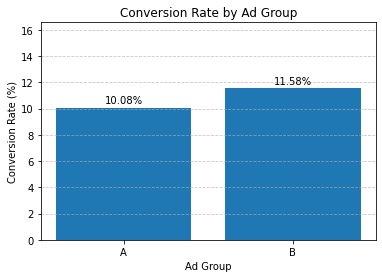

In [37]:
import matplotlib.pyplot as plt

conv_by_group = df.groupby('ad_group')['converted'].mean()* 100

plt.bar(conv_by_group.index, conv_by_group.values)
plt.title('Conversion Rate by Ad Group')
plt.xlabel('Ad Group')
plt.ylabel('Conversion Rate (%)')

for i, v in enumerate(conv_by_group.values):
    plt.text(i, v + 0.3, f"{v:.2f}%", ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(conv_by_group.values) + 5)

output_path = os.path.join("..","images","conversion_rate_by_ad_group.png")
plt.savefig(output_path, dpi = 100, bbox_inches = 'tight')
plt.show()

Finding:

Ad B shows a slightly higher conversion rate than Ad A. However, the difference appears small visually, suggesting that it may not be statistically significant — a conclusion confirmed by the hypothesis test.

Conversion rate by day AND ad group

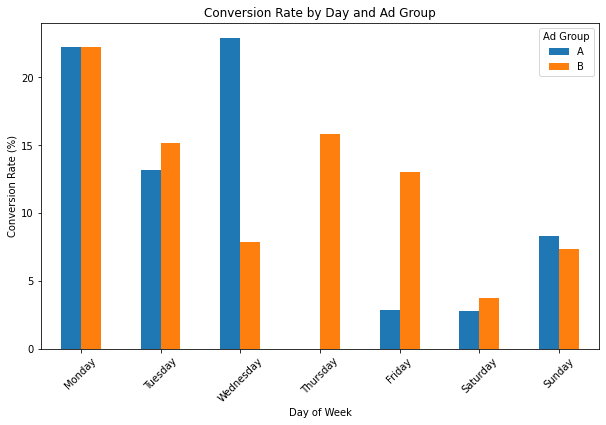

In [38]:
pivot = df.groupby(['day', 'ad_group'])['converted'].mean().unstack() * 100
pivot = pivot.reindex(day_order)

pivot.plot(kind='bar', figsize=(10,6))
plt.title('Conversion Rate by Day and Ad Group')
plt.xlabel('Day of Week')
plt.ylabel('Conversion Rate (%)')
plt.legend(title='Ad Group')
plt.xticks(rotation=45)

output_path = os.path.join("..","images","conversion_rate_by_day_and_ad_group.png")
plt.savefig(output_path, dpi = 100, bbox_inches = 'tight')
plt.show()

Findings:

While conversion rates vary across days, the sample sizes within each day are relatively small. As a result, these differences may be driven by random variation rather than true performance differences.

Business recommendations:

The observed variations suggest a potential interaction between Ad performance and day 
of the week.  This hypothesis could be further tested through a targeted A/B experiment 
designed specifically to evaluate time-based effects with sufficient sample size. 

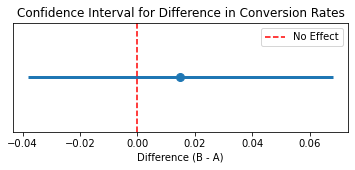

In [39]:
import matplotlib.pyplot as plt

# values
diff = 0.0149
lower = -0.038
upper = 0.068

plt.figure(figsize=(6,2))

# plot the CI as a horizontal line
plt.hlines(y=0, xmin=lower, xmax=upper,linewidth=3)

# plot the point estimate
plt.plot(diff, 0, 'o',markersize=8)

# vertical line at 0 (no effect)
plt.axvline(x=0, linestyle='--', color = 'red', label= 'No Effect')

plt.title('Confidence Interval for Difference in Conversion Rates')
plt.yticks([])

plt.xlabel('Difference (B - A)')
plt.legend()
output_path = os.path.join("..","images","confidence_interval.png")
plt.savefig(output_path,dpi = 100, bbox_inches = 'tight')
plt.show()

### Takeaway:
The 95% confidence interval ranges from -3.8 to 6.8 percentage points. The confidence interval crosses zero, indicating that the observed difference is not statistically significant.

## Final Conclusion:
Although Ad B shows a slightly higher conversion rate (+1.5 percentage points) the difference is not statistically significant (p = 0.29), and the confidence interval includes zero.  Additionally, the experiment is  underpowered, meaning it lacks sufficient sample size to detect small effects reliably.

Therefore, no definitive conclusion can be drawn, and a large-scale experiment is recommended before making a decision. 

## Limitations:
- The experiment is underpowered due to small sample size
- Conversion rates are simulated and may not reflect real-world complexity
- Time-based effects were explored but not formally tested. 
